In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

data = pd.read_csv(r'C:\Users\Hp\Downloads\train.csv')
data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y



STEP 2: Check Missing Values
Empty DataFrame
Columns: [Column, Missing_Count, Missing_Percentage]
Index: []


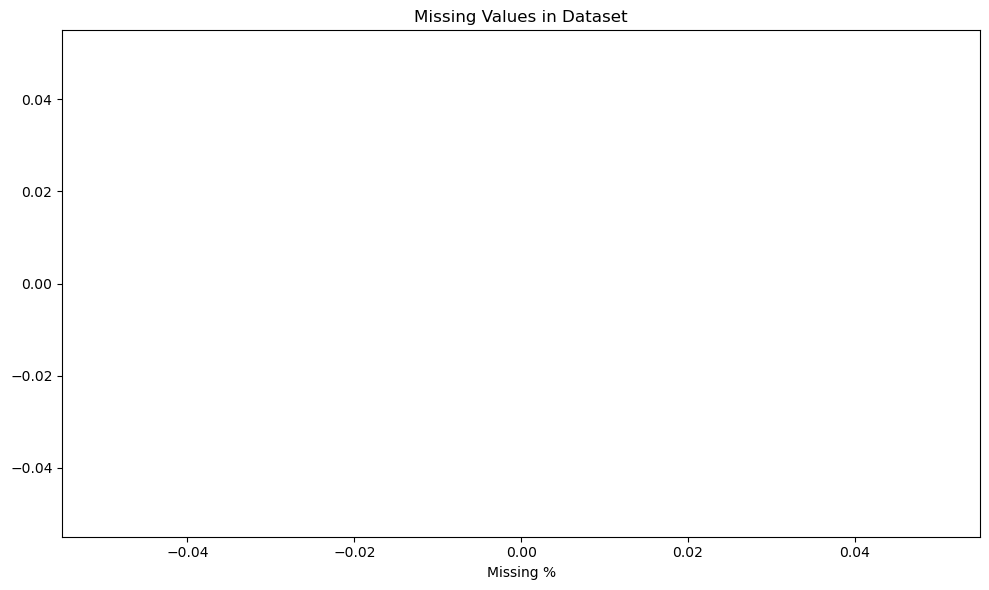

In [12]:
# STEP 2: Check for missing values

print("\n" + "=" * 80)
print("STEP 2: Check Missing Values")
print("=" * 80)
 
missing_data = pd.DataFrame({
    'Column': data.columns,
    'Missing_Count': data.isnull().sum(),
    'Missing_Percentage': (data.isnull().sum() / len(data)) * 100
})
missing_data = missing_data[missing_data['Missing_Count'] > 0].sort_values('Missing_Percentage', ascending=False)
print(missing_data)
 
# Visualize
plt.figure(figsize=(10, 6))
missing_data_sorted = missing_data.sort_values('Missing_Percentage', ascending=True)
plt.barh(missing_data_sorted['Column'], missing_data_sorted['Missing_Percentage'], color='coral')
plt.xlabel('Missing %')
plt.title('Missing Values in Dataset')
plt.tight_layout()
plt.savefig('01_missing_values.png')
plt.show()
 


In [13]:
# ============================================================================
# STEP 3: Fill missing values
# ============================================================================
print("\n" + "=" * 80)
print("STEP 3: Fill Missing Values")
print("=" * 80)
 
# Identify categorical and numerical columns
categorical_cols = data.select_dtypes(include=['object']).columns.tolist()
numerical_cols = data.select_dtypes(include=['int64', 'float64']).columns.tolist()
 
# Remove Loan_ID and Loan_Status
if 'Loan_ID' in categorical_cols:
    categorical_cols.remove('Loan_ID')
if 'Loan_Status' in categorical_cols:
    categorical_cols.remove('Loan_Status')
if 'Loan_Status' in numerical_cols:
    numerical_cols.remove('Loan_Status')
 
print(f"Categorical columns: {categorical_cols}")
print(f"Numerical columns: {numerical_cols}\n")
 
# Fill categorical with mode (most common value)
for col in categorical_cols:
    if data[col].isnull().sum() > 0:
        mode_value = data[col].mode()[0]
        data[col].fillna(mode_value, inplace=True)
        print(f"✓ {col}: Filled with '{mode_value}'")
 
# Fill numerical with median
for col in numerical_cols:
    if col != 'Loan_Status' and data[col].isnull().sum() > 0:
        median_value = data[col].median()
        data[col].fillna(median_value, inplace=True)
        print(f"✓ {col}: Filled with {median_value:.2f}")
 
# Handle Dependents (convert '3+' to 3)
if 'Dependents' in data.columns:
    data['Dependents'] = data['Dependents'].replace('3+', '3').astype(float)
    print(f"✓ Dependents: Converted '3+' to 3")
 
# Drop rows where Loan_Status is missing
if data['Loan_Status'].isnull().sum() > 0:
    print(f"\n✓ Dropping {data['Loan_Status'].isnull().sum()} rows with missing Loan_Status")
    data = data[data['Loan_Status'].notna()]
 
print(f"\nDataset shape after cleaning: {data.shape}")
print(f"Missing values remaining: {data.isnull().sum().sum()}")


STEP 3: Fill Missing Values
Categorical columns: ['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area']
Numerical columns: ['Dependents', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']

✓ Dependents: Converted '3+' to 3

Dataset shape after cleaning: (614, 13)
Missing values remaining: 0



STEP 4: Visualize Key Features


C:\Users\Hp\AppData\Local\Temp\ipykernel_21072\3684856195.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0, 2].boxplot(education_data, labels=education_levels)
C:\Users\Hp\AppData\Local\Temp\ipykernel_21072\3684856195.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1, 0].set_xticklabels(['Rejected (N)', 'Approved (Y)'])
C:\Users\Hp\AppData\Local\Temp\ipykernel_21072\3684856195.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 1].boxplot(employment_data, labels=employment_status)


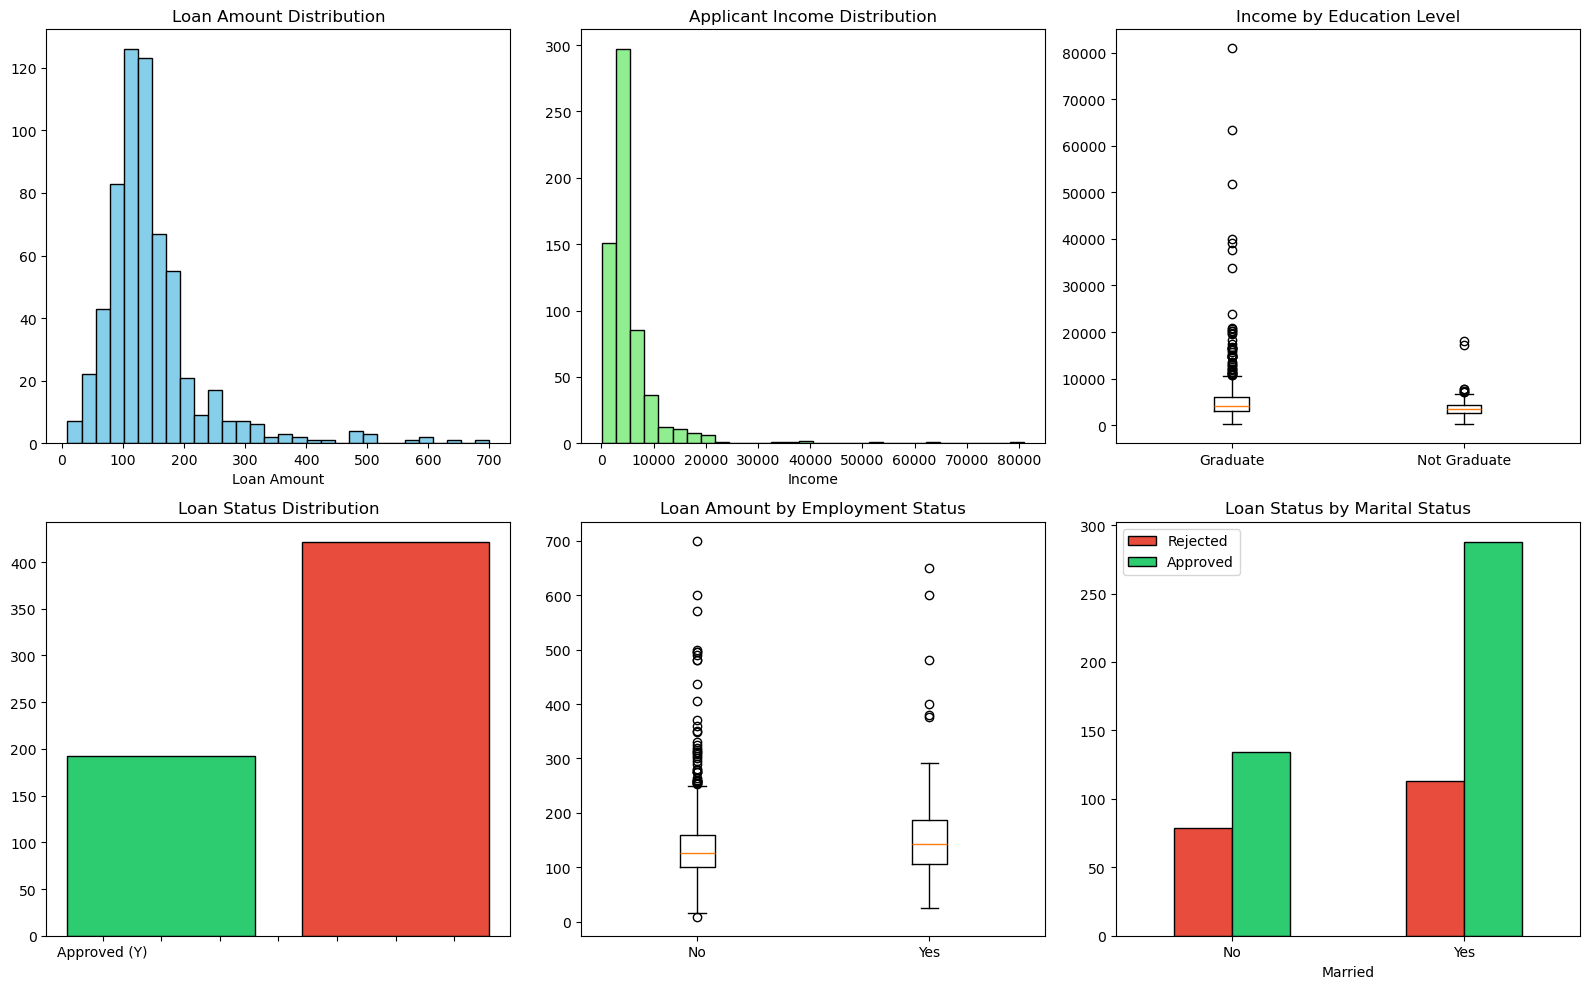

 Visualizations saved!


In [14]:
# ============================================================================
# STEP 4: Visualize key features
# ============================================================================
print("\n" + "=" * 80)
print("STEP 4: Visualize Key Features")
print("=" * 80)
 
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
 
# Plot 1: Loan Amount Distribution
axes[0, 0].hist(data['LoanAmount'], bins=30, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Loan Amount Distribution')
axes[0, 0].set_xlabel('Loan Amount')
 
# Plot 2: Applicant Income Distribution
axes[0, 1].hist(data['ApplicantIncome'], bins=30, color='lightgreen', edgecolor='black')
axes[0, 1].set_title('Applicant Income Distribution')
axes[0, 1].set_xlabel('Income')
 
# Plot 3: Income by Education
education_levels = data['Education'].unique()
education_data = [data[data['Education'] == edu]['ApplicantIncome'].values for edu in education_levels]
axes[0, 2].boxplot(education_data, labels=education_levels)
axes[0, 2].set_title('Income by Education Level')
 
# Plot 4: Loan Status (Target Variable)
loan_status_counts = data['Loan_Status'].value_counts()
colors = ['#e74c3c', '#2ecc71']
axes[1, 0].bar(loan_status_counts.index, loan_status_counts.values, color=colors, edgecolor='black')
axes[1, 0].set_title('Loan Status Distribution')
axes[1, 0].set_xticklabels(['Rejected (N)', 'Approved (Y)'])
 
# Plot 5: Loan Amount by Employment
employment_status = data['Self_Employed'].unique()
employment_data = [data[data['Self_Employed'] == status]['LoanAmount'].dropna().values for status in employment_status]
axes[1, 1].boxplot(employment_data, labels=employment_status)
axes[1, 1].set_title('Loan Amount by Employment Status')
 
# Plot 6: Marriage vs Approval
married_data = data.groupby('Married')['Loan_Status'].value_counts().unstack(fill_value=0)
married_data.plot(kind='bar', ax=axes[1, 2], color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[1, 2].set_title('Loan Status by Marital Status')
axes[1, 2].legend(['Rejected', 'Approved'])
axes[1, 2].tick_params(axis='x', rotation=0)
 
plt.tight_layout()
plt.savefig('02_eda_visualizations.png')
plt.show()
 
print(" Visualizations saved!")

In [6]:
# ============================================================================
# STEP 5: Map target variable and prepare features (FIXED VERSION)
# ============================================================================
print("\n" + "=" * 80)
print("STEP 5: Prepare Features")
print("=" * 80)

# First, check what values are in Loan_Status
print("Loan_Status values:")
print(data['Loan_Status'].unique())
print(f"\nValue counts:")
print(data['Loan_Status'].value_counts(dropna=False))

# Map Loan_Status - handle different cases
print("\nMapping Loan_Status...")
try:
    # First, convert to uppercase (handles 'y', 'Y', 'yes', 'YES', etc.)
    data['Loan_Status'] = data['Loan_Status'].astype(str).str.upper().str.strip()
    
    # Then map Y/N to 1/0
    data['Loan_Status'] = data['Loan_Status'].map({'Y': 1, 'N': 0})
    
    print("✓ Mapped Loan_Status: Y→1 (Approved), N→0 (Rejected)")
except Exception as e:
    print(f"Error in mapping: {e}")
    print("\nTrying alternative method...")
    data['Loan_Status'] = data['Loan_Status'].replace({'Y': 1, 'N': 0, 'y': 1, 'n': 0})
    print("✓ Mapped Loan_Status (alternative method)")

# Check for any remaining NaN after mapping
print(f"\nNaN count after mapping: {data['Loan_Status'].isnull().sum()}")
if data['Loan_Status'].isnull().sum() > 0:
    print("⚠️ Found NaN values. Dropping them...")
    data = data[data['Loan_Status'].notna()]
    print(f"New shape: {data.shape}")

# Separate features and target
print("\nCreating feature matrix (X) and target (y)...")
X = data.drop(['Loan_ID', 'Loan_Status'], axis=1)
y = data['Loan_Status']

print(f"X shape before encoding: {X.shape}")
print(f"X columns: {X.columns.tolist()}")

# Check for any NaN in X before encoding
print(f"\nNaN in X before encoding: {X.isnull().sum().sum()}")
if X.isnull().sum().sum() > 0:
    print("Filling remaining NaN values...")
    X = X.fillna(X.median(numeric_only=True))
    X = X.fillna(X.mode(numeric_only=True).iloc[0])
    print(f"NaN in X after filling: {X.isnull().sum().sum()}")

# One-hot encode categorical variables
print("\nOne-hot encoding categorical variables...")
try:
    X = pd.get_dummies(X, drop_first=True)
    print(f"✓ One-hot encoding successful!")
    print(f"Features after encoding: {X.shape[1]} columns")
except Exception as e:
    print(f"Error in one-hot encoding: {e}")
    print("Trying alternative method...")
    X = pd.get_dummies(X, drop_first=True, dummy_na=False)
    print(f"✓ Encoding completed with alternative method")

# Final safety checks
print(f"\n" + "="*50)
print("FINAL DATA CHECKS:")
print("="*50)
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Missing in X: {X.isnull().sum().sum()}")
print(f"Missing in y: {y.isnull().sum()}")
print(f"X data type: {X.dtypes.unique()}")
print(f"y data type: {y.dtype}")
print(f"y values: {y.unique()}")
print(f"y value counts:\n{y.value_counts()}")

if X.isnull().sum().sum() == 0 and y.isnull().sum() == 0:
    print("\n✓ All checks passed! Ready for next step.")
else:
    print("\n  Warning: Still have missing values!")


STEP 5: Prepare Features
Loan_Status values:
['Y' 'N']

Value counts:
Loan_Status
Y    422
N    192
Name: count, dtype: int64

Mapping Loan_Status...
✓ Mapped Loan_Status: Y→1 (Approved), N→0 (Rejected)

NaN count after mapping: 0

Creating feature matrix (X) and target (y)...
X shape before encoding: (614, 11)
X columns: ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area']

NaN in X before encoding: 0

One-hot encoding categorical variables...
✓ One-hot encoding successful!
Features after encoding: 12 columns

FINAL DATA CHECKS:
X shape: (614, 12)
y shape: (614,)
Missing in X: 0
Missing in y: 0
X data type: [dtype('float64') dtype('int64') dtype('bool')]
y data type: int64
y values: [1 0]
y value counts:
Loan_Status
1    422
0    192
Name: count, dtype: int64

✓ All checks passed! Ready for next step.


In [7]:
# ============================================================================
# STEP 6: Split data into training and testing
# ============================================================================
print("\n" + "=" * 80)
print("STEP 6: Train/Test Split")
print("=" * 80)
 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, 
)
 
print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")
print(f"\nTraining distribution:")
print(y_train.value_counts())
print(f"\nTesting distribution:")
print(y_test.value_counts())
 
# ============================================================================
# STEP 7: Train Logistic Regression Model
# ============================================================================
print("\n" + "=" * 80)
print("STEP 7: Train Logistic Regression Model")
print("=" * 80)
 
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)
print("✓ Model trained successfully!")
 
# Make predictions
y_pred = model.predict(X_test)
print(f"✓ Predictions made on test set")


STEP 6: Train/Test Split
Training set: 491 samples
Testing set: 123 samples

Training distribution:
Loan_Status
1    342
0    149
Name: count, dtype: int64

Testing distribution:
Loan_Status
1    80
0    43
Name: count, dtype: int64

STEP 7: Train Logistic Regression Model
✓ Model trained successfully!
✓ Predictions made on test set


C:\Users\Hp\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [8]:
# ============================================================================
# STEP 8: Evaluate the model
# ============================================================================
print("\n" + "=" * 80)
print("STEP 8: Model Evaluation")
print("=" * 80)
 
# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"(Out of {len(y_test)} predictions, {int(accuracy * len(y_test))} were correct)")
 
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print(f"\nConfusion Matrix:")
print(cm)
print(f"\nBreakdown:")
print(f"  True Negatives (Correctly said 'Rejected'):  {cm[0, 0]}")
print(f"  False Positives (Wrongly said 'Approved'):   {cm[0, 1]}")
print(f"  False Negatives (Wrongly said 'Rejected'):   {cm[1, 0]}")
print(f"  True Positives (Correctly said 'Approved'):  {cm[1, 1]}")


STEP 8: Model Evaluation
Accuracy: 78.86%
(Out of 123 predictions, 97 were correct)

Confusion Matrix:
[[18 25]
 [ 1 79]]

Breakdown:
  True Negatives (Correctly said 'Rejected'):  18
  False Positives (Wrongly said 'Approved'):   25
  False Negatives (Wrongly said 'Rejected'):   1
  True Positives (Correctly said 'Approved'):  79



STEP 9: Visualize Confusion Matrix


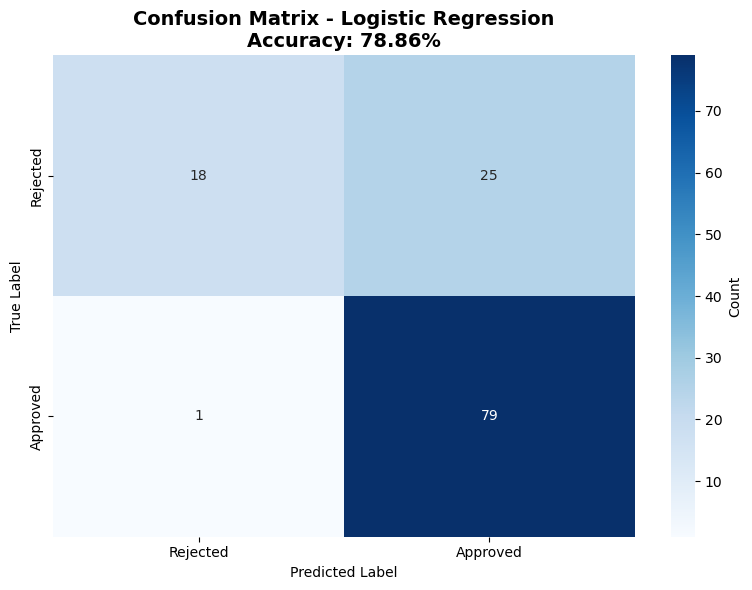

✓ Confusion matrix saved!


In [9]:
# ============================================================================
# STEP 9: Visualize Confusion Matrix
# ============================================================================
print("\n" + "=" * 80)
print("STEP 9: Visualize Confusion Matrix")
print("=" * 80)
 
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Rejected', 'Approved'], 
            yticklabels=['Rejected', 'Approved'],
            cbar_kws={'label': 'Count'})
plt.title(f'Confusion Matrix - Logistic Regression\nAccuracy: {accuracy * 100:.2f}%', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('03_confusion_matrix.png')
plt.show()
 
print("✓ Confusion matrix saved!")
 

In [17]:
from sklearn.metrics import precision_score, recall_score, f1_score
# ============================================================================
# STEP 10: Additional Metrics
# ============================================================================
print("\n" + "=" * 80)
print("STEP 10: Additional Metrics")
print("=" * 80)
 

 
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
 
print(f"Precision: {precision * 100:.2f}%")
print(f"  (Of all loans marked 'Approved', {precision * 100:.2f}% were actually approved)")
 
print(f"\nRecall: {recall * 100:.2f}%")
print(f"  (Of all actual approvals, the model caught {recall * 100:.2f}%)")
 
print(f"\nF1-Score: {f1:.4f}")
print(f"  (Balance between precision and recall)")


STEP 10: Additional Metrics
Precision: 75.96%
  (Of all loans marked 'Approved', 75.96% were actually approved)

Recall: 98.75%
  (Of all actual approvals, the model caught 98.75%)

F1-Score: 0.8587
  (Balance between precision and recall)


In [15]:
#Output 
#Summary of All of these
print("\n" + "=" * 80)
print(" PROJECT COMPLETE!")
print("=" * 80)
print(f"""
Results Summary:
✓ Data Cleaned: {data.shape[0]} samples, {X.shape[1]} features
✓ Accuracy: {accuracy * 100:.2f}%
✓ Precision: {precision * 100:.2f}%
✓ Recall: {recall * 100:.2f}%
 
Generated Files:
1. 01_missing_values.png - Missing data analysis
2. 02_eda_visualizations.png - Exploratory visualizations
3. 03_confusion_matrix.png - Model performance matrix
 
Model Performance: {'GOOD ✓' if accuracy > 0.75 else 'FAIR' if accuracy > 0.65 else 'NEEDS IMPROVEMENT'}
""")
print("=" * 80)


 PROJECT COMPLETE!

Results Summary:
✓ Data Cleaned: 614 samples, 12 features
✓ Accuracy: 78.86%
✓ Precision: 75.96%
✓ Recall: 98.75%

Generated Files:
1. 01_missing_values.png - Missing data analysis
2. 02_eda_visualizations.png - Exploratory visualizations
3. 03_confusion_matrix.png - Model performance matrix

Model Performance: GOOD ✓

